In [1]:
!pip install xgboost -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

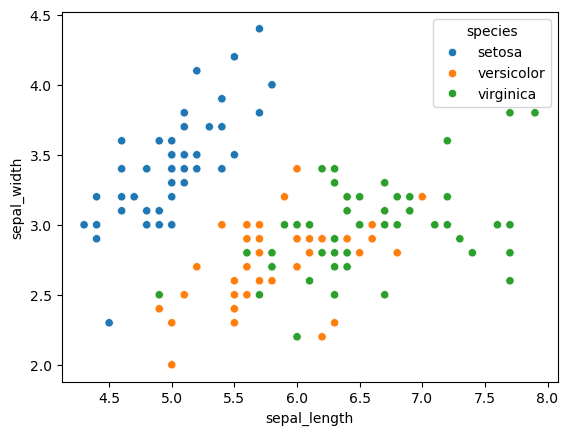

In [4]:
# plot the data
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df)

In [5]:
X = df.drop('species',axis=1)
y = df['species']

In [6]:
# encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
# Train the decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [9]:
y_pred = dt.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score

In [11]:
print('Accuracy Score :', accuracy_score(y_test,y_pred))
print('Precision Score :', precision_score(y_test,y_pred, average='micro'))
print('Recall Score :', recall_score(y_test,y_pred, average='micro'))
print('F1 Score :', f1_score(y_test,y_pred, average='micro'))

Accuracy Score : 1.0
Precision Score : 1.0
Recall Score : 1.0
F1 Score : 1.0


In [12]:
print('Confusion Matrix :\n ', confusion_matrix(y_test,y_pred))
print('\nClassification Report :\n ', classification_report(y_test,y_pred))

Confusion Matrix :
  [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report :
                precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [13]:
# train the Xgboosty model
xgb = XGBClassifier()
xgb.fit(X_train,y_train)

# predict the test data
y_pred = xgb.predict(X_test)

print('Accuracy Score :', accuracy_score(y_test,y_pred))
print('Precision Score :', precision_score(y_test,y_pred, average='micro'))
print('Recall Score :', recall_score(y_test,y_pred, average='micro'))
print('F1 Score :', f1_score(y_test,y_pred, average='micro'))

Accuracy Score : 1.0
Precision Score : 1.0
Recall Score : 1.0
F1 Score : 1.0


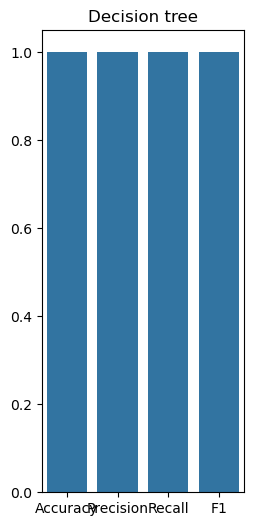

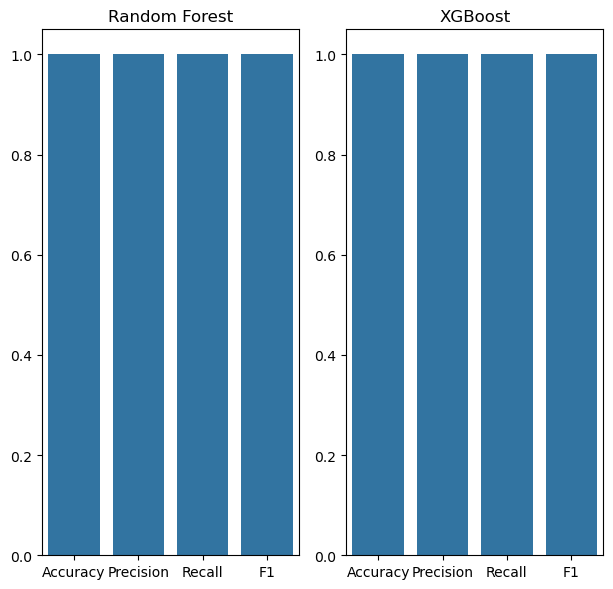

In [16]:
# Make a bar plot showing each of the matrix with respect to the model
plt.figure(figsize=(12,6))
plt.subplot(1,4,1)
sns.barplot(x=['Accuracy','Precision','Recall','F1'], y=[accuracy_score(y_test,y_pred), precision_score(y_test,y_pred, average='micro'),recall_score(y_test,y_pred, average='micro'),f1_score(y_test,y_pred, average='micro')])
plt.title('Decision tree')
plt.figure(figsize=(12,6))
plt.subplot(1,4,2)
sns.barplot(x=['Accuracy','Precision','Recall','F1'], y=[accuracy_score(y_test,y_pred), precision_score(y_test,y_pred, average='micro'),recall_score(y_test,y_pred, average='micro'),f1_score(y_test,y_pred, average='micro')])
plt.title('Random Forest')
plt.subplot(1,4,3)
sns.barplot(x=['Accuracy','Precision','Recall','F1'], y=[accuracy_score(y_test,y_pred), precision_score(y_test,y_pred, average='micro'),recall_score(y_test,y_pred, average='micro'),f1_score(y_test,y_pred, average='micro')])
plt.title('XGBoost')
plt.tight_layout()
plt.show()